# MODEL TRANING

## 1.1 IMPORT PACKAGES 

In [84]:
# Basic imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Model Traning imports
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor,GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

## 1.2 Import Data

In [85]:
df = pd.read_csv(r"C:\Users\sharief\Documents\projects\ML-Project\notebook\data\StudentsPerformance.csv")

In [86]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## 1.3 Preparing X and y variables

In [87]:
X = df.drop(['math score'],axis=1)


In [88]:
y = df['math score']

## 1.4 Creat column transformer with 3 types of transformers

In [89]:

num_features = [i for i in X.columns if X[i].dtype != 'O']
cat_features = [i for i in X.columns if X[i].dtype == 'O']

from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    [
        ('Column Transformer',OneHotEncoder(drop='first'),cat_features),
        ('Numeric Transformer',StandardScaler(),num_features)
        
    ]
)

In [90]:
X = preprocessor.fit_transform(X)
X

array([[ 0.        ,  1.        ,  0.        , ...,  1.        ,
         0.19399858,  0.39149181],
       [ 0.        ,  0.        ,  1.        , ...,  0.        ,
         1.42747598,  1.31326868],
       [ 0.        ,  1.        ,  0.        , ...,  1.        ,
         1.77010859,  1.64247471],
       ...,
       [ 0.        ,  0.        ,  1.        , ...,  0.        ,
         0.12547206, -0.20107904],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.60515772,  0.58901542],
       [ 0.        ,  0.        ,  0.        , ...,  1.        ,
         1.15336989,  1.18158627]], shape=(1000, 14))

## 1.5 Seperate it into train test and split

In [91]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_train.shape

((800, 14), (800, 14))

## 1.6 Create Evaluate funtion to give all metrics after model traning

In [104]:
def evaluate_model(true,pred):
    mae = mean_absolute_error(true,pred)
    mse = mean_squared_error(true,pred)
    rmse = np.sqrt(mean_squared_error(true,pred))
    r2score = r2_score(true,pred)
    return mae,rmse,r2score
    

## 1.7 Model Traning

In [105]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso' : Lasso(),
    'SVR' : SVR(),
    'KNN' : KNeighborsRegressor(),
    'Decision Tree' : DecisionTreeRegressor(),
    'Random Forest' : RandomForestRegressor(),
    'Ada Boost' : AdaBoostRegressor(),
    'Gradient Boost' : GradientBoostingRegressor(),
    'Cat Boost' : CatBoostRegressor(),
    'XGB' : XGBRegressor()
}

model_list = []
r2_list= []

for name,model in (models.items()):
    model.fit(X_train,y_train) # train model

    #make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    #Evaluate Train and Test dataset

    mae_train,rmse_train,r2score_train = evaluate_model(y_train,y_train_pred)
    mae_test,rmse_test,r2score_test = evaluate_model(y_test,y_test_pred)

    print(f"{name}:")
    model_list.append(name)

    print("Model performance for traning set")
    print("Root Mean Square: {:.4f}.".format(rmse_train))
    print("Mean Absolute Error: {:.4f}.".format(mae_train))
    print("R2 Score: {:.4f}.".format(r2score_train))

    print("----------------------------------------------")

    print("Model performance for test set")
    print("Root Mean Square: {:.4f}.".format(rmse_test))
    print("Mean Absolute Error: {:.4f}.".format(mae_test))
    print("R2 Score: {:.4f}.".format(r2score_test))
    r2_list.append(r2score_test)

    print("*"*35)
    print('\n')    

Linear Regression:
Model performance for traning set
Root Mean Square: 5.3231.
Mean Absolute Error: 4.2667.
R2 Score: 0.8743.
----------------------------------------------
Model performance for test set
Root Mean Square: 5.3940.
Mean Absolute Error: 4.2148.
R2 Score: 0.8804.
***********************************


Ridge:
Model performance for traning set
Root Mean Square: 5.3235.
Mean Absolute Error: 4.2650.
R2 Score: 0.8743.
----------------------------------------------
Model performance for test set
Root Mean Square: 5.3936.
Mean Absolute Error: 4.2125.
R2 Score: 0.8805.
***********************************


Lasso:
Model performance for traning set
Root Mean Square: 6.5938.
Mean Absolute Error: 5.2063.
R2 Score: 0.8071.
----------------------------------------------
Model performance for test set
Root Mean Square: 6.5197.
Mean Absolute Error: 5.1579.
R2 Score: 0.8253.
***********************************


SVR:
Model performance for traning set
Root Mean Square: 6.7454.
Mean Absolute 

In [106]:
pd.DataFrame(zip(model_list,r2_list),columns=['Model Name','R2 Score']).sort_values(by='R2 Score',ascending=False)

,Model Name,R2 Score
1,Ridge,0.880451
0,Linear Regression,0.880433
8,Gradient Boost,0.872418
6,Random Forest,0.853810
7,Ada Boost,0.850386
9,Cat Boost,0.849801
2,Lasso,0.825320
10,XGB,0.825046
4,KNN,0.776335
3,SVR,0.713014


#### let's pick linear regression

## 2. Linear Regression

In [107]:
lr = LinearRegression()
lr.fit(X_train,y_train)
y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)

score = r2_score(y_test,y_test_pred) * 100

print("Accuracy of model is {:.2f}".format(score))

Accuracy of model is 88.04


## 3. Plot y_pred and y_test

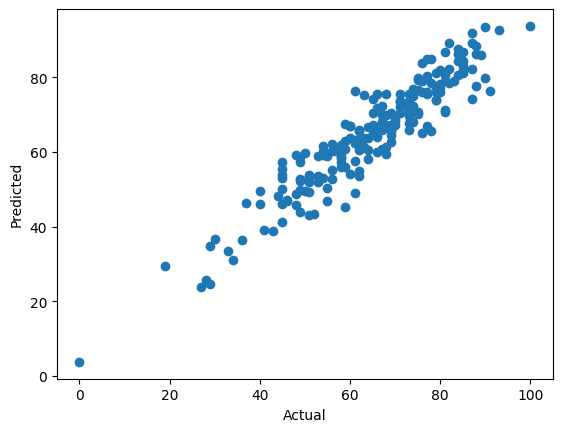

In [109]:
plt.scatter(y_test,y_test_pred);
plt.xlabel("Actual");
plt.ylabel("Predicted");

<Axes: xlabel='math score'>

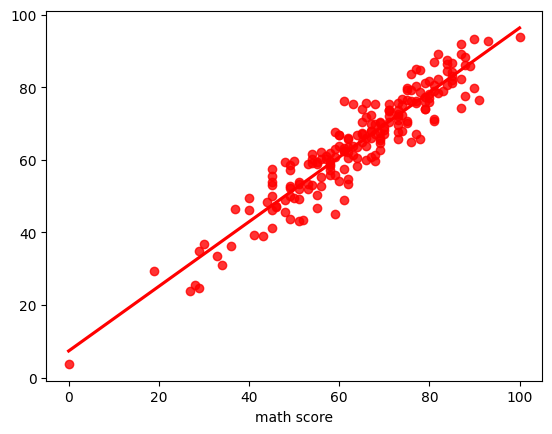

In [113]:
sns.regplot(x=y_test,y=y_test_pred,ci=None,color='red')

## 4. Difference between Acutal and Predicted

In [114]:
pred_df = pd.DataFrame({'Acutal Value':y_test,'Predicted Value': y_test_pred,'Difference':y_test-y_test_pred})
pred_df

,Acutal Value,Predicted Value,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
